Libraries and Packages

In [396]:
import numpy as np                  # For array handling
import random                       # For Mersenne Twister (uniform)
import matplotlib.pyplot as plt     # For data plotting
import pandas as pd

Random Number Generators

In [ ]:
def float_to_binary(num, max_bits=53):
    if not (0 <= num < 1):
        raise ValueError("Number must be between 0 and 1 (inclusive of 0, exclusive of 1).")

    binary_list = []
    for _ in range(max_bits):
        num *= 2
        bit = int(num)
        binary_list.append(bit)
        num -= bit
        if num == 0:
            break
        
    return np.array(binary_list)

def random_start(b_adic):
    sum = 0
    for i in range(np.size(b_adic)):
        sum = sum + b_adic[i] * (2**i)

    return sum

def random_shift(vds, shift):
    vds_shifted = (vds + shift) % 1

    return vds_shifted

def van_der_corput(num):    # Generates the i-th element of the Van de Corput sequence 
    if(num < 0):
        raise ValueError("The index for the Halton sequence has to be greater than equal to 0.")
    
    bin_list = [int(i) for i in list('{0:0b}'.format(num))]
    bin_list.reverse()
    bin_length = np.size(bin_list)

    sum = 0
    for i in range(bin_length):
        sum = sum + ( bin_list[i] / 2**(i+1))
        
    return sum

def vdc_start(size, tol):   # Generates the randomly started n elements of the Van de Corput sequence
    if(size < 0):
        raise ValueError("The size of the sequence has to be greater than equal to 0.")
    
    u = random.random()
    max_bits = tol
    rep = float_to_binary(u, max_bits)
    start = random_start(rep)

    return np.array([van_der_corput((i+1)+start) for i in range(size)])

def vdc_shift(size):    # Generates the randomly shifted n elements of the Van de Corput sequence
    if(size < 0):
        raise ValueError("The size of the sequence has to be greater than equal to 0.")
    
    u = random.random()
    base_sequence =  np.array([van_der_corput((i+1)) for i in range(size)])
    shifted_sequence = random_shift(base_sequence, u)

    return shifted_sequence

def mt19937(size):      # Default Mersenne Twister (takes in size and generates a pseudo-random array of that size)
    if(size < 0):
        raise ValueError("The size of the sequence has to be greater than equal to 0.")
    
    return np.array([random.random() for _ in range(size)])

Integral Estimate

In [ ]:
def quadrature(support):
    size = np.size(support)
    if(size == 0):
       return 0
    vals = np.exp(support)                   # Change function here as a parameter
    integral = (np.sum(vals)) / size         # Compute the normalized sum
    
    return integral                          # return estimate

Numerical Quadrature

In [ ]:
def mt_quadrature(size,trials):
    estimates = np.zeros(trials)
    for i in range(trials):
        x_vals = mt19937(size)
        estimates[i] = quadrature(x_vals)

    return estimates
    
def vdc_quadrature_shift(size,trials):
    estimates = np.zeros(trials)
    for i in range(trials):
        x_vals = vdc_shift(size)
        estimates[i] = quadrature(x_vals)

    return estimates

def vdc_quadrature_start(size, trials, tol):
    estimates = np.zeros(trials)
    for i in range(trials):
        x_vals = vdc_start(size, tol)
        estimates[i] = quadrature(x_vals)

    return estimates

Run Parameters

In [ ]:
n = 10000           # Size of Quadrature (number of terms)
m = 40              # Number of Trials

# For the random start algorithm
max_bits = 32       # This determines tolerence up to 2**(-max_bits) for the 2-adic number

true_value = np.e - 1.0

estimates_mt = mt_quadrature(n,m)
estimates_vdc_shift = vdc_quadrature_shift(n,m)
estimates_vdc_start = vdc_quadrature_start(n,m, max_bits)

Testing

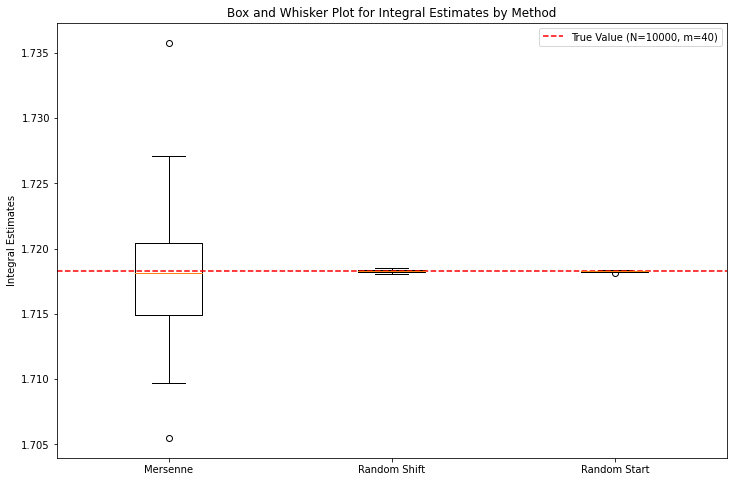

In [401]:
# Calculate means and standard deviations
mean_mt, std_mt = np.mean(estimates_mt), np.std(estimates_mt)
mean_vdc_shift, std_vdc_shift = np.mean(estimates_vdc_shift), np.std(estimates_vdc_shift)
mean_vdc_start, std_vdc_start = np.mean(estimates_vdc_start), np.std(estimates_vdc_start)

# Create the box plot
plt.figure(figsize=(12, 8))
plt.boxplot([estimates_mt, estimates_vdc_shift, estimates_vdc_start], 
            labels=['Mersenne', 'Random Shift', 'Random Start'])

# Add a line for the true value
plt.axhline(y=true_value, color='red', linestyle='--', label=f'True Value (N={n}, m={m})')

# Add labels, title, and legend
plt.ylabel('Integral Estimates')
plt.title('Box and Whisker Plot for Integral Estimates by Method')
plt.legend()

# Display the plot
plt.show()

         Method      Mean  Standard Deviation
0      Mersenne  1.718093            0.005152
1  Random Shift  1.718287            0.000108
2  Random Start  1.718271            0.000056


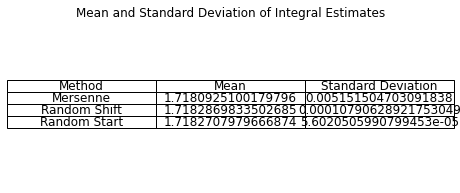

In [402]:
# Create and display the table
data = {
    'Method': ['Mersenne', 'Random Shift', 'Random Start'],
    'Mean': [mean_mt, mean_vdc_shift, mean_vdc_start],
    'Standard Deviation': [std_mt, std_vdc_shift, std_vdc_start]
}
df = pd.DataFrame(data)

# Print the table to console
print(df)

# Optionally display the table with Matplotlib
plt.figure(figsize=(8, 3))
plt.axis('off')
table = plt.table(cellText=df.values, colLabels=df.columns, loc='center', cellLoc='center')
table.auto_set_font_size(False)
table.set_fontsize(12)
plt.title('Mean and Standard Deviation of Integral Estimates')
plt.show()

Large Parameterized Experiment

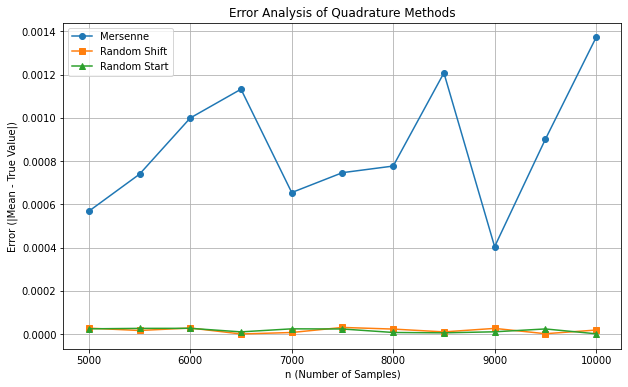

In [405]:
n_values = np.arange(5000, 10001, 500)
# Arrays to store errors
errors_mt = []
errors_vdc_shift = []
errors_vdc_start = []

# Loop through each value of n, calculate means and errors
for n in n_values:
    estimates_mt = mt_quadrature(n, m)
    estimates_vdc_shift = vdc_quadrature_shift(n, m)
    estimates_vdc_start = vdc_quadrature_start(n, m, max_bits)

    mean_mt = np.mean(estimates_mt)
    mean_vdc_shift = np.mean(estimates_vdc_shift)
    mean_vdc_start = np.mean(estimates_vdc_start)

    # Calculate absolute error for each method
    errors_mt.append(abs(mean_mt - true_value))
    errors_vdc_shift.append(abs(mean_vdc_shift - true_value))
    errors_vdc_start.append(abs(mean_vdc_start - true_value))

# Plot the errors as a function of n
plt.figure(figsize=(10, 6))
plt.plot(n_values, errors_mt, marker='o', label='Mersenne')
plt.plot(n_values, errors_vdc_shift, marker='s', label='Random Shift')
plt.plot(n_values, errors_vdc_start, marker='^', label='Random Start')

# Add labels, title, and legend
plt.xlabel('n (Number of Samples)')
plt.ylabel('Error (|Mean - True Value|)')
plt.title('Error Analysis of Quadrature Methods')
plt.legend()
plt.grid(True)

# Display the plot
plt.show()